In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
# from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
# from sklearn.ensemble import VotingClassifier
from sklearn.metrics import confusion_matrix,precision_score,classification_report,f1_score,roc_curve,roc_auc_score,auc,accuracy_score,recall_score
from sklearn import metrics
%matplotlib inline

In [5]:
df = pd.read_excel(r"C:\Users\Lenovo\OneDrive\Desktop\Imarticus\machine learning\Bank_Personal_Loan_Modelling.xlsx",
                                           sheet_name = 'Data')

In [7]:
df['Personal Loan'].value_counts()

Personal Loan
0    4520
1     480
Name: count, dtype: int64

In [9]:
df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [13]:
df.shape

(5000, 14)

In [15]:
df.describe()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937913,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747666,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [23]:
df.apply(lambda x: len(x.unique()))

Age                    45
Experience             47
Income                162
ZIP Code              467
Family                  4
CCAvg                 108
Education               3
Mortgage              347
Personal Loan           2
Securities Account      2
CD Account              2
Online                  2
CreditCard              2
dtype: int64

## Data cleaning

In [26]:
df[df['Experience'] < 0]['Experience'].count()

52

In [30]:
# Cheching the correlation of Experience with other variables.
df.corr()['Experience']

Age                   0.994215
Experience            1.000000
Income               -0.046574
ZIP Code             -0.028626
Family               -0.052563
CCAvg                -0.050089
Education             0.013152
Mortgage             -0.010582
Personal Loan        -0.007413
Securities Account   -0.001232
CD Account            0.010353
Online                0.013898
CreditCard            0.008967
Name: Experience, dtype: float64

In [32]:
df['Experience'] = df['Experience'].abs()

In [34]:
# checking if there are records with negative experience
df[df['Experience'] < 0]['Experience'].count()

0

In [36]:
df['CCAvg'] = df['CCAvg'].astype(float)*12
df

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,91107,4,19.2,1,0,0,1,0,0,0
1,45,19,34,90089,3,18.0,1,0,0,1,0,0,0
2,39,15,11,94720,1,12.0,1,0,0,0,0,0,0
3,35,9,100,94112,1,32.4,2,0,0,0,0,0,0
4,35,8,45,91330,4,12.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29,3,40,92697,1,22.8,3,0,0,0,0,1,0
4996,30,4,15,92037,4,4.8,1,85,0,0,0,1,0
4997,63,39,24,93023,2,3.6,3,0,0,0,0,0,0
4998,65,40,49,90034,3,6.0,2,0,0,0,0,1,0


### Detecting outliers

In [39]:
numerical = ['Age','Income','Experience','CCAvg','Mortgage']
Q1 = df[numerical].quantile(0.25)
Q3 = df[numerical].quantile(0.75)
IQR = Q3 - Q1
out = (df[numerical] < (Q1 - 1.5 * IQR)) | (df[numerical] > (Q3 + 1.5 * IQR))
out.sum()

Age             0
Income         96
Experience      0
CCAvg         324
Mortgage      291
dtype: int64

<Axes: xlabel='Income'>

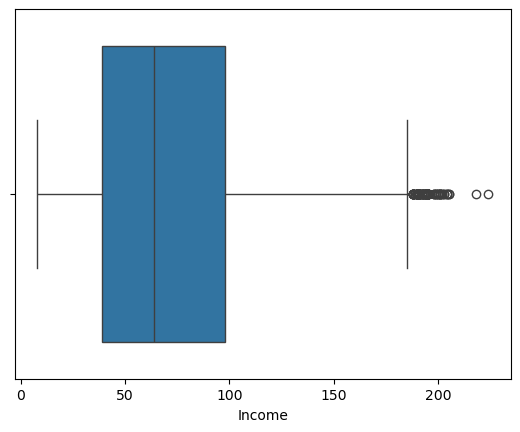

In [41]:
#univariate analysis
sns.boxplot(x=df['Income'])

<Axes: xlabel='CCAvg'>

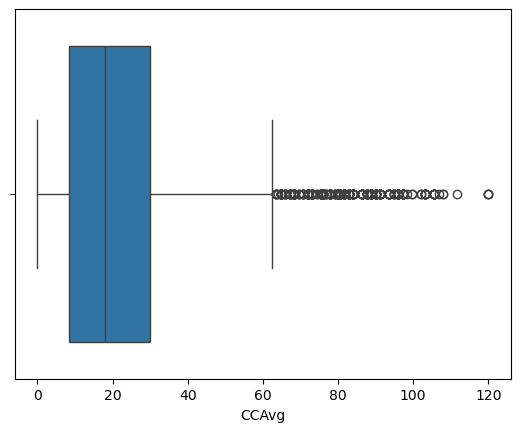

In [43]:
sns.boxplot(x=df['CCAvg'])

<Axes: xlabel='Mortgage'>

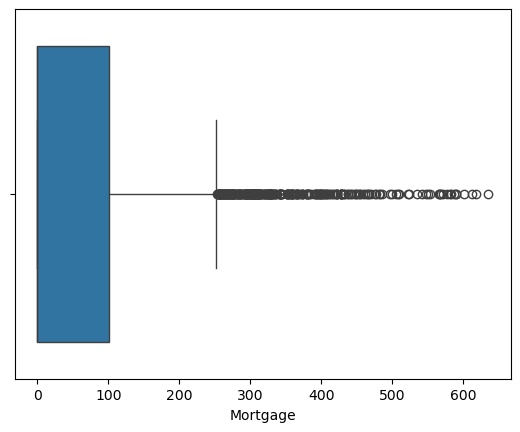

In [45]:
sns.boxplot(x=df['Mortgage'])

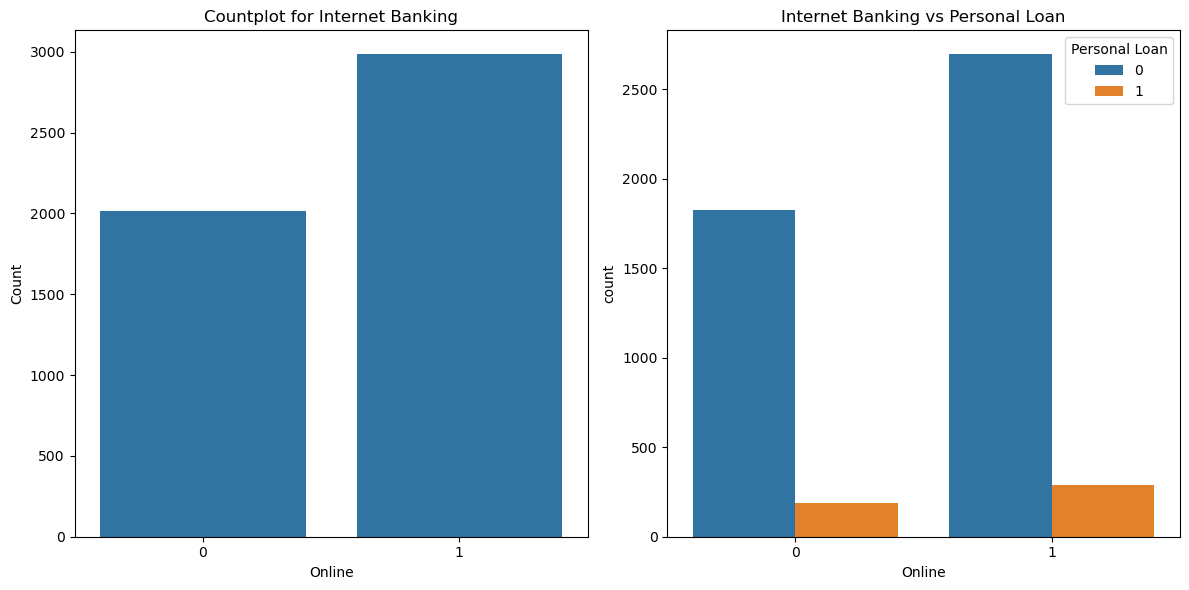

In [47]:
# Bivariate analysis

fig ,axes = plt.subplots(nrows=1, ncols=2,figsize=(12,6))

# Internet Banking vs Personal Loan (with hue)
sns.countplot(x='Online', hue='Personal Loan', data=df, ax=axes[1])
axes[1].set_title('Internet Banking vs Personal Loan')
axes[1].legend(title='Personal Loan', loc='upper right')

# Countplot for Internet Banking only (without hue)
sns.countplot(x='Online', data=df, ax=axes[0])
axes[0].set_title('Countplot for Internet Banking')
axes[0].set_ylabel('Count')

# Ensure the layout doesn't overlap
plt.tight_layout()

# Show the plot
plt.show()

In [49]:
from ydata_profiling import ProfileReport

In [51]:
profile = ProfileReport(df)


In [53]:
profile.to_notebook_iframe()    #  use .to_file('report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

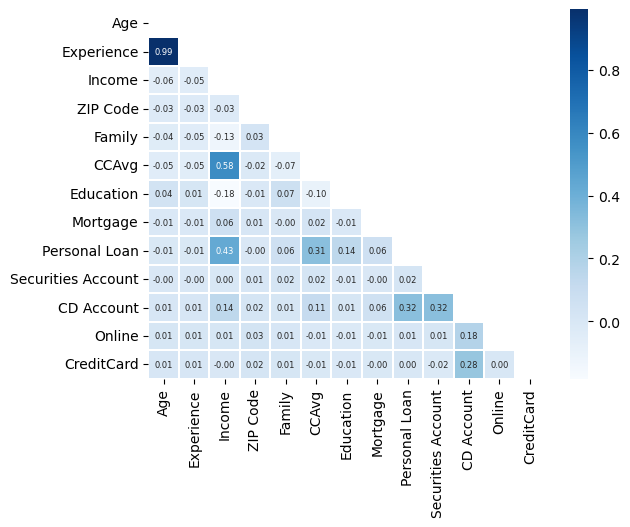

In [55]:
# Compute Spearman's correlation
corr = df.corr(method='spearman')

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot the heatmap
sns.heatmap(corr, mask=mask, annot=True, cmap='Blues', fmt='.2f', linewidths=0.2,annot_kws={"size": 6})
plt.show()

### Distribution of numerical features 

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Income'}>,
        <Axes: title={'center': 'Experience'}>],
       [<Axes: title={'center': 'CCAvg'}>,
        <Axes: title={'center': 'Mortgage'}>, <Axes: >]], dtype=object)

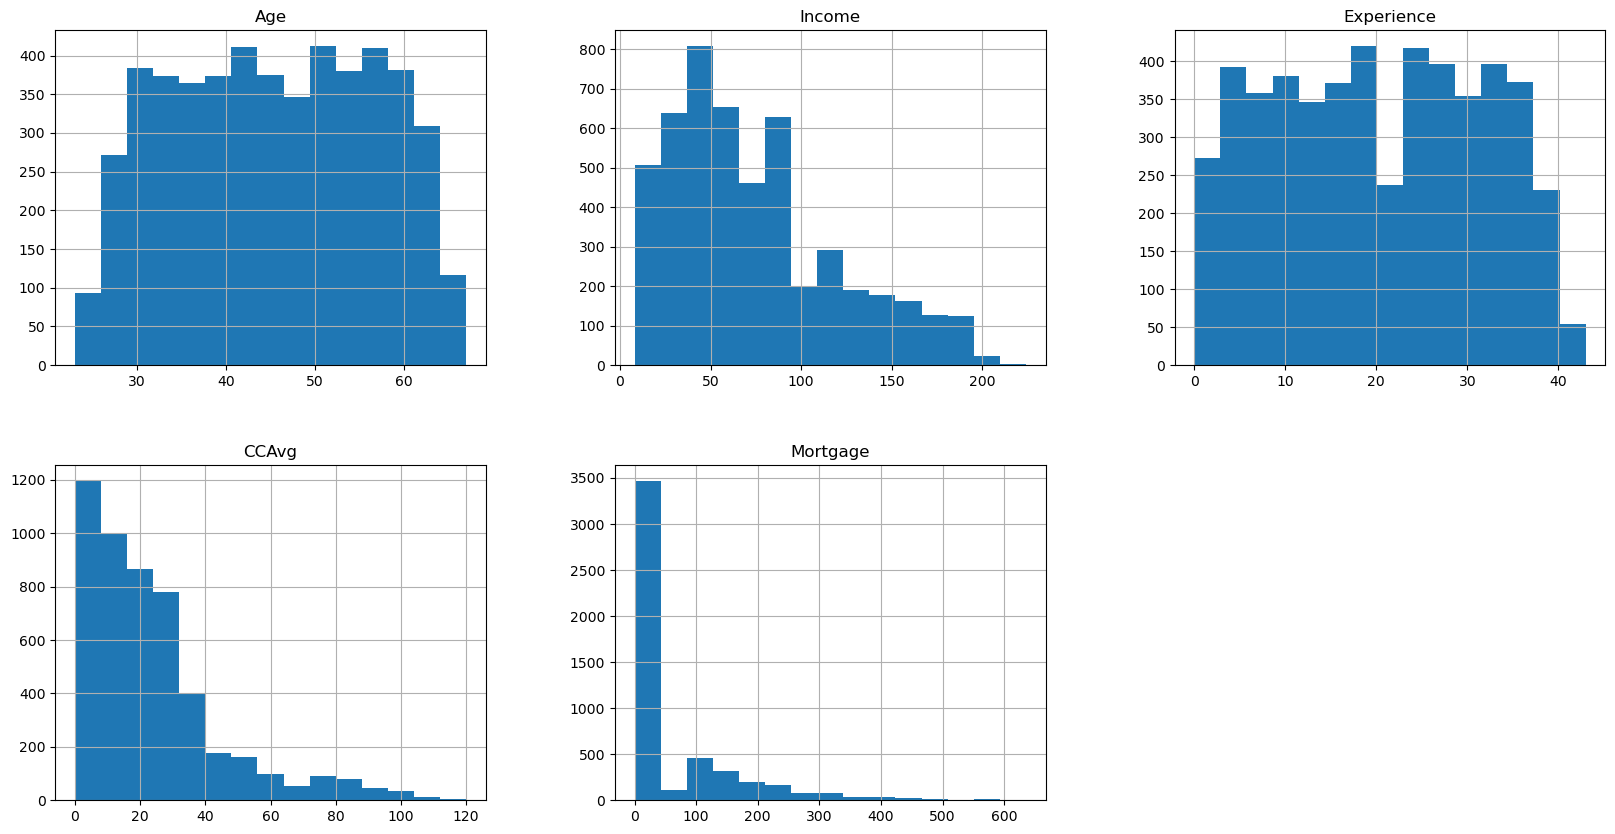

In [58]:
df[numerical].hist(bins=15, figsize=(20, 10), layout=(2, 3))

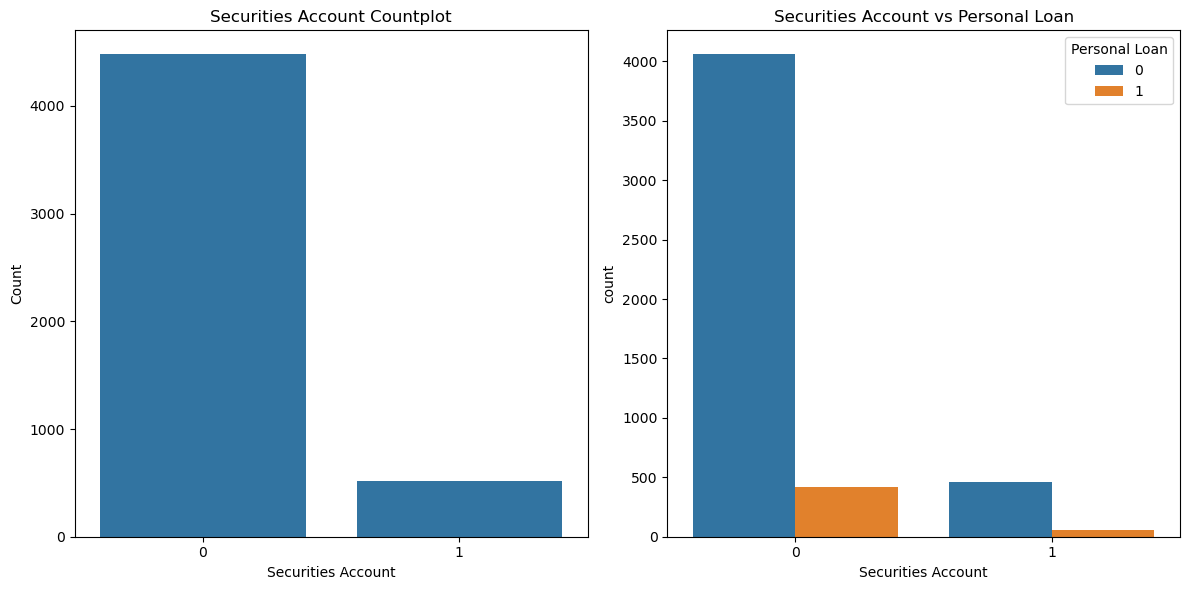

In [60]:
# Using sns.countplot() for visualizing the counts


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Countplot for Securities Account vs Personal Loan
sns.countplot(x='Securities Account', hue='Personal Loan', data=df, ax=axes[1])
axes[1].set_title('Securities Account vs Personal Loan')
axes[1].legend(title='Personal Loan', loc='upper right')

# Countplot for Securities Account only
sns.countplot(x='Securities Account', data=df, ax=axes[0])
axes[0].set_title('Securities Account Countplot')
axes[0].set_ylabel('Count')  # Add y-axis label for clarity

# Show the plots
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

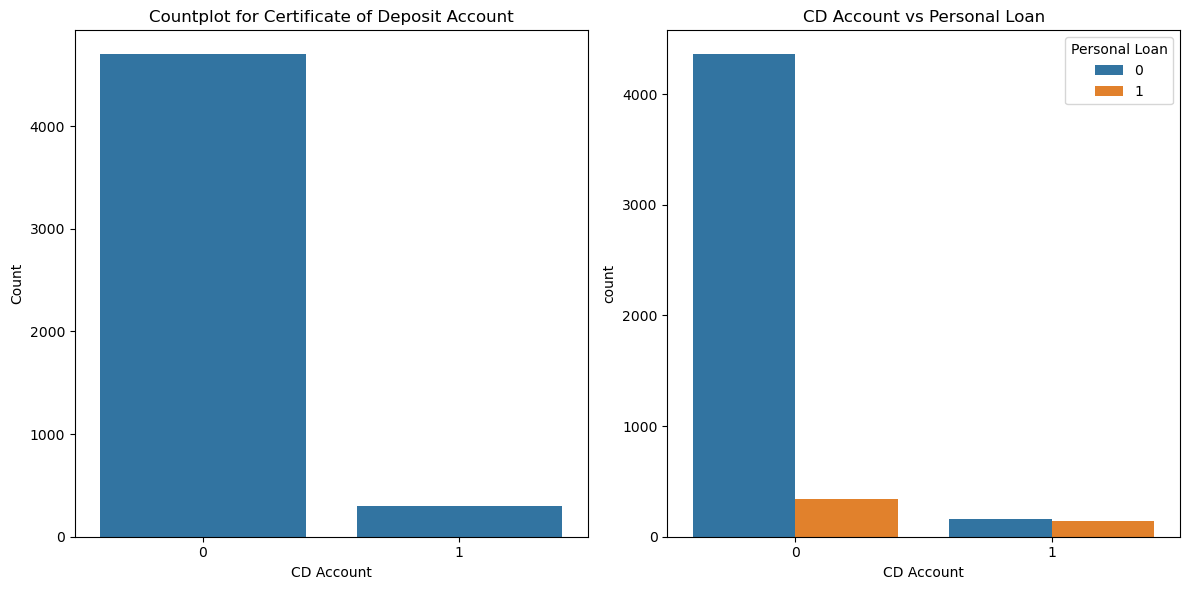

In [62]:
# Using sns.countplot() for visualizing the counts

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Countplot for CD Account vs Personal Loan
sns.countplot(x='CD Account', hue='Personal Loan', data=df, ax=axes[1])
axes[1].set_title('CD Account vs Personal Loan')
axes[1].legend(title='Personal Loan', loc='upper right')  # Position the legend

# Countplot for CD Account only
sns.countplot(x='CD Account', data=df, ax=axes[0])
axes[0].set_title('Countplot for Certificate of Deposit Account')
axes[0].set_ylabel('Count')  # Add y-axis label for clarity

# Show the plots
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

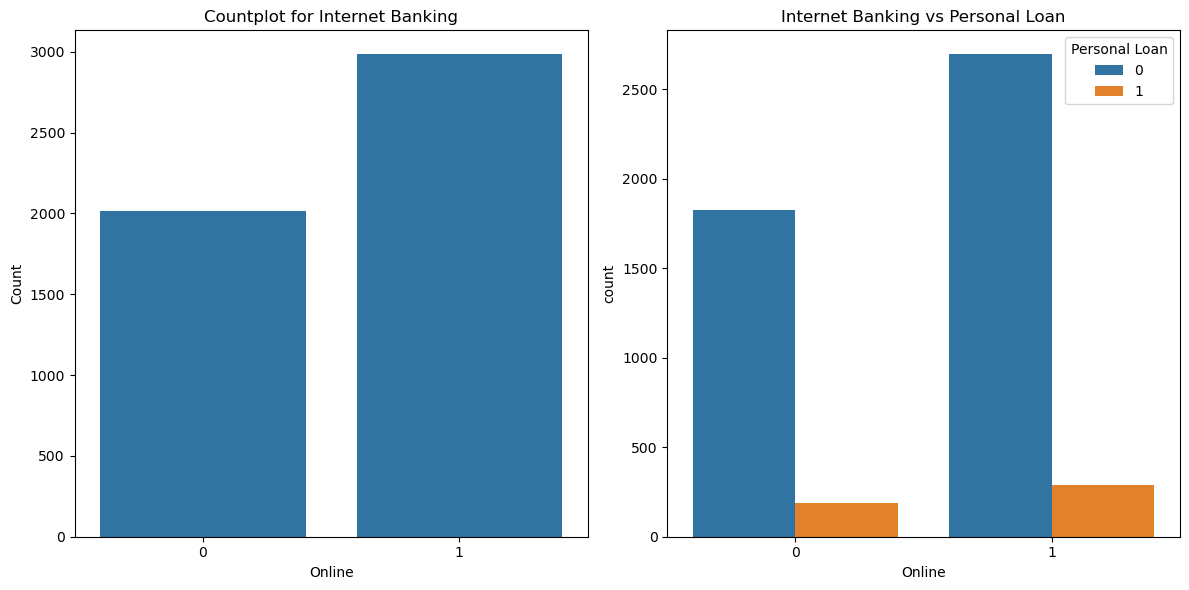

In [64]:
# Using sns.countplot() for visualizing the counts

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Internet Banking vs Personal Loan (with hue)
sns.countplot(x='Online', hue='Personal Loan', data=df, ax=axes[1])
axes[1].set_title('Internet Banking vs Personal Loan')
axes[1].legend(title='Personal Loan', loc='upper right')

# Countplot for Internet Banking only (without hue)
sns.countplot(x='Online', data=df, ax=axes[0])
axes[0].set_title('Countplot for Internet Banking')
axes[0].set_ylabel('Count')

# Ensure the layout doesn't overlap
plt.tight_layout()

# Show the plot
plt.show()


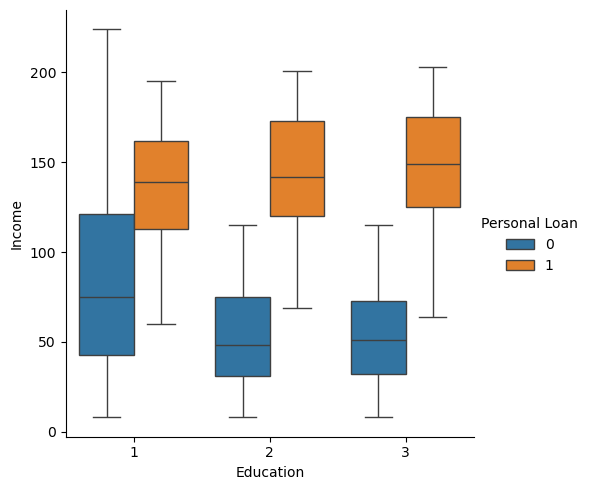

In [66]:
sns.catplot(x='Education', y = 'Income', data = df,kind= 'box',hue='Personal Loan')

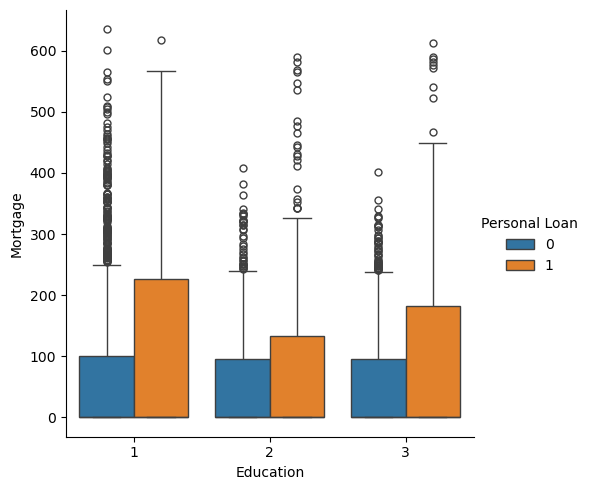

In [68]:
sns.catplot(x='Education',y='Mortgage',data=df,hue='Personal Loan',kind='box')

### Dsitribution of target column

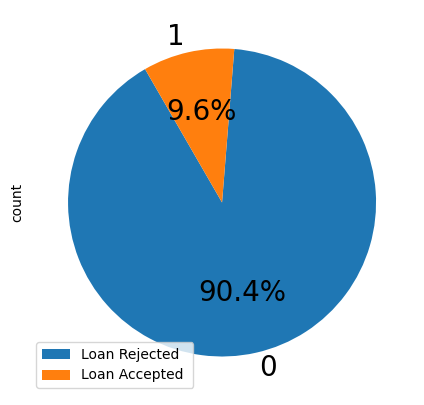

In [71]:
fig,ax = plt.subplots( figsize=(7,5) )
df['Personal Loan'].value_counts(sort=False).plot(kind='pie',autopct='%1.1f%%', fontsize= 20,startangle=120)
plt.legend(['Loan Rejected','Loan Accepted '])
plt.show()

### Corelation amaong the attributes

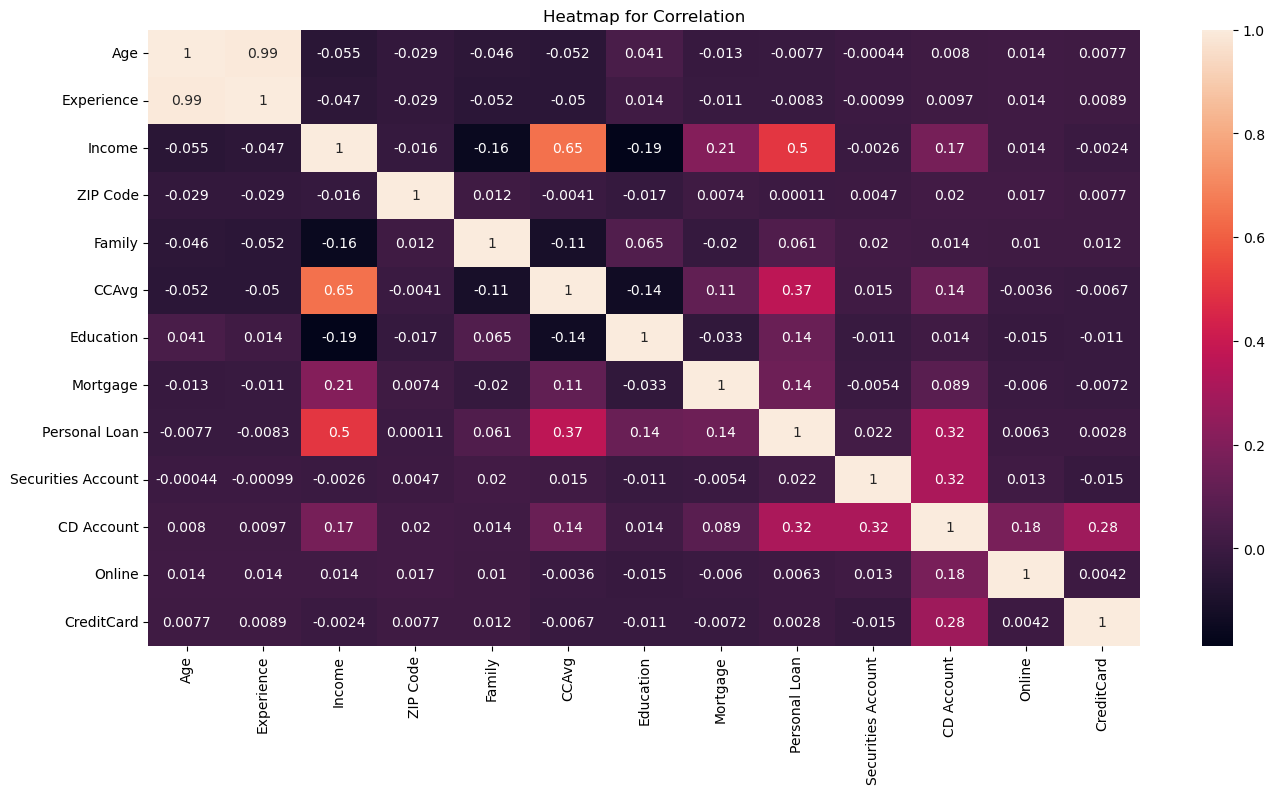

In [73]:
# Plot for Visualising the correlation between variables and Target Column.

fig,ax = plt.subplots( figsize=(16,8) )
sns.heatmap(df.corr(),annot=True)
plt.title('Heatmap for Correlation')
plt.show()

### Separating the target column

In [78]:
# Creating seperate DataSets for Target column('Personal Loan') named as 'y' and rest of the features in 'X' 

y = df["Personal Loan"]
X = df.drop("Personal Loan",axis=1)

In [80]:
y.value_counts()

Personal Loan
0    4520
1     480
Name: count, dtype: int64

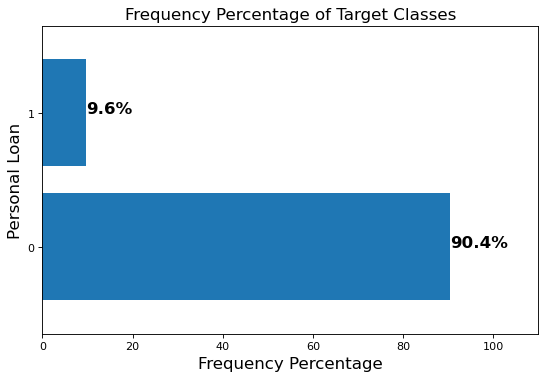

In [84]:
plt.figure(dpi=80)

# Plot frequency percentages barplot
df['Personal Loan'].value_counts(normalize=True).mul(100).plot(kind='barh', width=0.8, figsize=(8,5))

# Add frequency percentages to the plot
labels = df['Personal Loan'].value_counts(normalize=True).mul(100).round(1)
for i in labels.index:
    plt.text(labels[i], i, str(labels[i])+ '%', fontsize=15, weight='bold')

plt.xlim([0, 110])
plt.xlabel('Frequency Percentage', fontsize=15)
plt.ylabel('Personal Loan', fontsize=15)
plt.title('Frequency Percentage of Target Classes', fontsize=15)
plt.show()

## Splitting the data

In [87]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0,stratify=y)

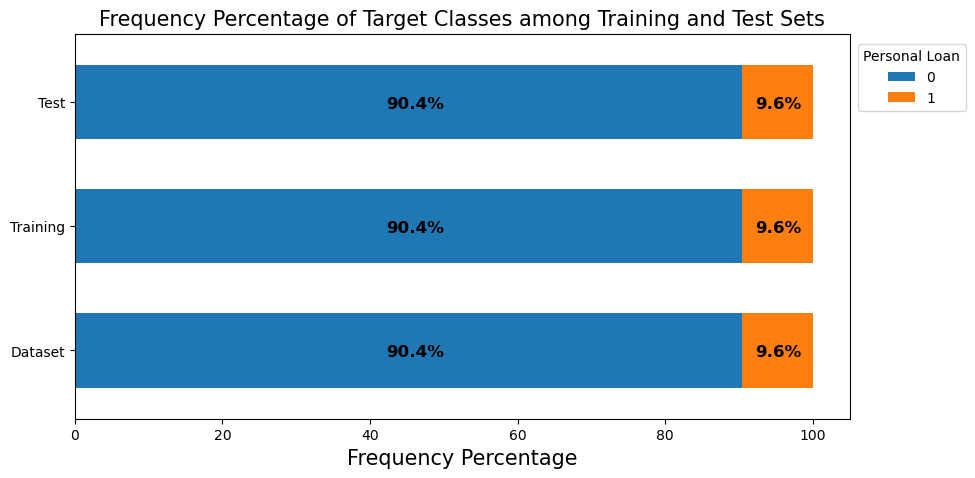

In [89]:
# Define a dataframe containing frequency percentages
df_perc = pd.concat([y.value_counts(normalize=True).mul(100).round(1),
                     y_train.value_counts(normalize=True).mul(100).round(1),
                     y_test.value_counts(normalize=True).mul(100).round(1)], axis=1)
df_perc.columns=['Dataset','Training','Test']
df_perc = df_perc.T

# Plot frequency percentages barplot
df_perc.plot(kind='barh', stacked=True, figsize=(10,5), width=0.6)

# Add the percentages to our plot
for idx, val in enumerate([*df_perc.index.values]):
    for (percentage, y_location) in zip(df_perc.loc[val], df_perc.loc[val].cumsum()):
        plt.text(x=(y_location - percentage) + (percentage / 2)-3,
                 y=idx - 0.05,
                 s=f'{percentage}%', 
                 color="black",
                 fontsize=12,
                 fontweight="bold")

plt.legend(title='Personal Loan', loc=(1.01,0.8))
plt.xlabel('Frequency Percentage', fontsize=15)
plt.title('Frequency Percentage of Target Classes among Training and Test Sets', fontsize=15)
plt.show()            

### Scaling the features

In [92]:
sc = StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled= sc.transform(X_test)

## Creating different ML classification models

### Logistic Regression

In [96]:
lr = LogisticRegression()
lr.fit(X_train_scaled,y_train)
lr_pred = lr.predict(X_test_scaled)
lr_accu_test = lr.score(X_test_scaled,y_test)
lr_accu_train = lr.score(X_train_scaled,y_train)
lr_f1 = f1_score(y_test,lr_pred)
print("Training Accuracy :",lr_accu_train)
print('Training Accuracy :',lr_accu_test)
print('F1 Score :',lr_f1)
print('Logistic Regression confusion matrix :\n\n', confusion_matrix(y_test,lr_pred))

Training Accuracy : 0.952
Training Accuracy : 0.9493333333333334
F1 Score : 0.7007874015748031
Logistic Regression confusion matrix :

 [[1335   21]
 [  55   89]]


### KNN

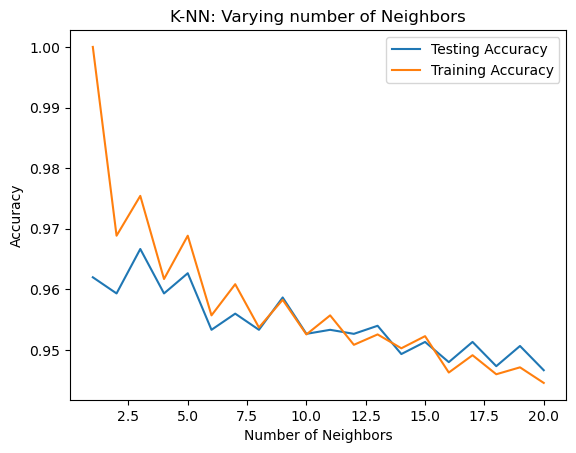

In [101]:
neighbors = np.arange(1,21)
train_accuracy = np.empty(len(neighbors))
test_accuracy = np.empty(len(neighbors))

for i,k in enumerate(neighbors):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled,y_train)
    train_accuracy[i] = knn.score(X_train_scaled,y_train)
    test_accuracy[i] = knn.score(X_test_scaled,y_test)

plt.title('K-NN: Varying number of Neighbors')
plt.plot(neighbors, test_accuracy, label = 'Testing Accuracy')
plt.plot(neighbors, train_accuracy, label = 'Training Accuracy')
plt.legend()
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
plt.show()

In [103]:
#testing accuracy is the highest for 'n_neighbors'=3
knn= KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled,y_train)
knn_predict = knn.predict(X_test_scaled)
knn_accu_test = knn.score(X_test_scaled,y_test)
knn_accu_train = knn.score(X_train_scaled,y_train)
knn_f1 = f1_score(y_test,knn_predict)
print("Training Accuracy :", knn_accu_train)
print("Testing accuracy  :",knn_accu_test)
print("F1 Score :",knn_f1)
print("KNN Confusion matrix :\n\n", confusion_matrix(y_test,knn_predict))

Training Accuracy : 0.9754285714285714
Testing accuracy  : 0.9666666666666667
F1 Score : 0.8
KNN Confusion matrix :

 [[1350    6]
 [  44  100]]


## Decision Trees

In [106]:
# Creating CART model with max_depth = 5

dt = DecisionTreeClassifier(criterion='entropy',max_depth=1)
dt.fit(X_train_scaled,y_train)
dt_pred = dt.predict(X_test_scaled)
dt_training = dt.score(X_train_scaled,y_train)
dt_testing = dt.score(X_test_scaled,y_test)
dt_precision = precision_score(y_test,dt_pred)
dt_f1 = f1_score(y_test,dt_pred)
print("Traing Accuracy :", dt_training)
print("Testing Accuracy :",dt_testing )
print("F1 Score: ",dt_f1 )
print('Decision Tree Confusion matrix :\n\n',confusion_matrix(y_test, dt_pred))

Traing Accuracy : 0.904
Testing Accuracy : 0.904
F1 Score:  0.0
Decision Tree Confusion matrix :

 [[1356    0]
 [ 144    0]]


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## Random Forest

In [109]:
rf = RandomForestClassifier(criterion='entropy',max_depth=50,n_estimators=50)
rf.fit(X_train_scaled,y_train)
rf_pred = rf.predict(X_test_scaled)
rf_training = rf.score(X_train_scaled,y_train)
rf_testing = rf.score(X_test_scaled,y_test)
rf_precision = precision_score(y_test,rf_pred)
rf_f1 = f1_score(y_test,rf_pred)
print("Traing Accuracy :", rf_training)
print("Testing Accuracy :",rf_testing )
print("F1 Score: ",rf_f1 )
print('Random Forest Confusion matrix :\n\n',confusion_matrix(y_test, rf_pred) )

Traing Accuracy : 1.0
Testing Accuracy : 0.9886666666666667
F1 Score:  0.9386281588447652
Random Forest Confusion matrix :

 [[1353    3]
 [  14  130]]


In [111]:
print('F1 Score\n :',classification_report(y_test, rf_pred))

F1 Score
 :               precision    recall  f1-score   support

           0       0.99      1.00      0.99      1356
           1       0.98      0.90      0.94       144

    accuracy                           0.99      1500
   macro avg       0.98      0.95      0.97      1500
weighted avg       0.99      0.99      0.99      1500



## Bagging Classifier

In [116]:
bg = BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=500,bootstrap=True,max_samples=100)
bg.fit(X_train_scaled,y_train)
bg_pred = bg.predict(X_test_scaled)
bg_training = bg.score(X_train_scaled,y_train)
bg_testing = bg.score(X_test_scaled,y_test)
bg_precision = precision_score(y_test,bg_pred)
bg_f1 = f1_score(y_test,bg_pred)
print("Traing Accuracy :", bg_training)
print("Testing Accuracy :",bg_testing )
print("F1 Score: ",bg_f1 )
print('Bagging Classifier Confusion matrix :\n\n',confusion_matrix(y_test, bg_pred) )

Traing Accuracy : 0.976
Testing Accuracy : 0.9746666666666667
F1 Score:  0.8480000000000001
Bagging Classifier Confusion matrix :

 [[1356    0]
 [  38  106]]


In [118]:
print('F1 Score\n :',classification_report(y_test, bg_pred))

F1 Score
 :               precision    recall  f1-score   support

           0       0.97      1.00      0.99      1356
           1       1.00      0.74      0.85       144

    accuracy                           0.97      1500
   macro avg       0.99      0.87      0.92      1500
weighted avg       0.98      0.97      0.97      1500



## AdaBoost Classifier

In [121]:
ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2),n_estimators=10,
                         learning_rate=0.5)
ada.fit(X_train_scaled,y_train)
ada_pred = ada.predict(X_test_scaled)
ada_training = ada.score(X_train_scaled,y_train)
ada_testing = ada.score(X_test_scaled,y_test)
ada_f1 = f1_score(y_test,ada_pred)
ada_precision = precision_score(y_test,ada_pred)
print("Traing Accuracy :", ada_training)
print("Testing Accuracy :",ada_testing )
print("F1 Score: ",ada_f1 )
print('AdaBoost Classifier Confusion matrix :\n\n',confusion_matrix(y_test, ada_pred) )

Traing Accuracy : 0.9865714285714285
Testing Accuracy : 0.986
F1 Score:  0.924731182795699
AdaBoost Classifier Confusion matrix :

 [[1350    6]
 [  15  129]]


In [123]:
print('F1 Score\n :',classification_report(y_test, ada_pred))

F1 Score
 :               precision    recall  f1-score   support

           0       0.99      1.00      0.99      1356
           1       0.96      0.90      0.92       144

    accuracy                           0.99      1500
   macro avg       0.97      0.95      0.96      1500
weighted avg       0.99      0.99      0.99      1500



## Gradient Boost Classifier

In [126]:
gbc = GradientBoostingClassifier(learning_rate=0.02,n_estimators=65)
gbc.fit(X_train_scaled,y_train)
gbc_pred = gbc.predict(X_test_scaled)
gbc_training = gbc.score(X_train_scaled,y_train)
gbc_testing = gbc.score(X_test_scaled,y_test)
gbc_f1 = f1_score(y_test,gbc_pred)
gbc_precision = precision_score(y_test,gbc_pred)
print("Traing Accuracy :", gbc_training)
print("Testing Accuracy :",gbc_testing )
print("F1 Score: ",gbc_f1 )
print('Gradient Classifier Confusion matrix :\n\n',confusion_matrix(y_test, gbc_pred) )


Traing Accuracy : 0.9808571428571429
Testing Accuracy : 0.9813333333333333
F1 Score:  0.8947368421052632
Gradient Classifier Confusion matrix :

 [[1353    3]
 [  25  119]]


In [128]:
print('F1 Score\n :',classification_report(y_test, gbc_pred))

F1 Score
 :               precision    recall  f1-score   support

           0       0.98      1.00      0.99      1356
           1       0.98      0.83      0.89       144

    accuracy                           0.98      1500
   macro avg       0.98      0.91      0.94      1500
weighted avg       0.98      0.98      0.98      1500



In [132]:
# ROC for Random Forest
rf_prob = rf.predict_proba(X_test_scaled)
fpr,tpr,thresh=roc_curve(y_test,rf_prob[:,1])
auc1 = auc(fpr,tpr)
print("Area under the curve for Random Forest ", auc1)

#ROC for Bagging
bg_prob = bg.predict_proba(X_test_scaled)
fpr1,tpr1,thresh1=roc_curve(y_test,bg_prob[:,1])
auc2 = auc(fpr1,tpr1)
print("Area under the curve for Bagging ", auc2)

#ROC for AdaBoost
ada_prob = ada.predict_proba(X_test_scaled)
fpr2,tpr2,thresh2=roc_curve(y_test,ada_prob[:,1])
auc3 = auc(fpr2,tpr2)
print("Area under the curve for AdaBoost ", auc3)

#ROC for GradientBoost
gbc_prob = gbc.predict_proba(X_test_scaled)
fpr3,tpr3,thresh3=roc_curve(y_test,gbc_prob[:,1])
auc4 = auc(fpr3,tpr3)
print("Area under the curve for  Gradient ", auc4)

lr_prob = lr.predict_proba(X_test_scaled)
lr_fpr,lr_tpr,lr_thresh=roc_curve(y_test,lr_prob[:,1])
lr_auc = auc(lr_fpr,lr_tpr)
print("Area under the curve for  Logistic Regression ", lr_auc)

dt_prob = dt.predict_proba(X_test_scaled)
dt_fpr,dt_tpr,dt_thresh=roc_curve(y_test,dt_prob[:,1])
dt_auc = auc(dt_fpr,dt_tpr)
print("Area under the curve for Decision Trees ", dt_auc)


knn_prob = knn.predict_proba(X_test_scaled)
knn_fpr,knn_tpr,knn_thresh=roc_curve(y_test,knn_prob[:,1])
knn_auc = auc(knn_fpr,knn_tpr)
print("Area under the curve for KNN ", knn_auc)


Area under the curve for Random Forest  0.993759730416257
Area under the curve for Bagging  0.9936265773516879
Area under the curve for AdaBoost  0.9953370821042281
Area under the curve for  Gradient  0.9968939487053425
Area under the curve for  Logistic Regression  0.956617707309079
Area under the curve for Decision Trees  0.8735558013765978
Area under the curve for KNN  0.9269092100950509


<Figure size 640x480 with 0 Axes>

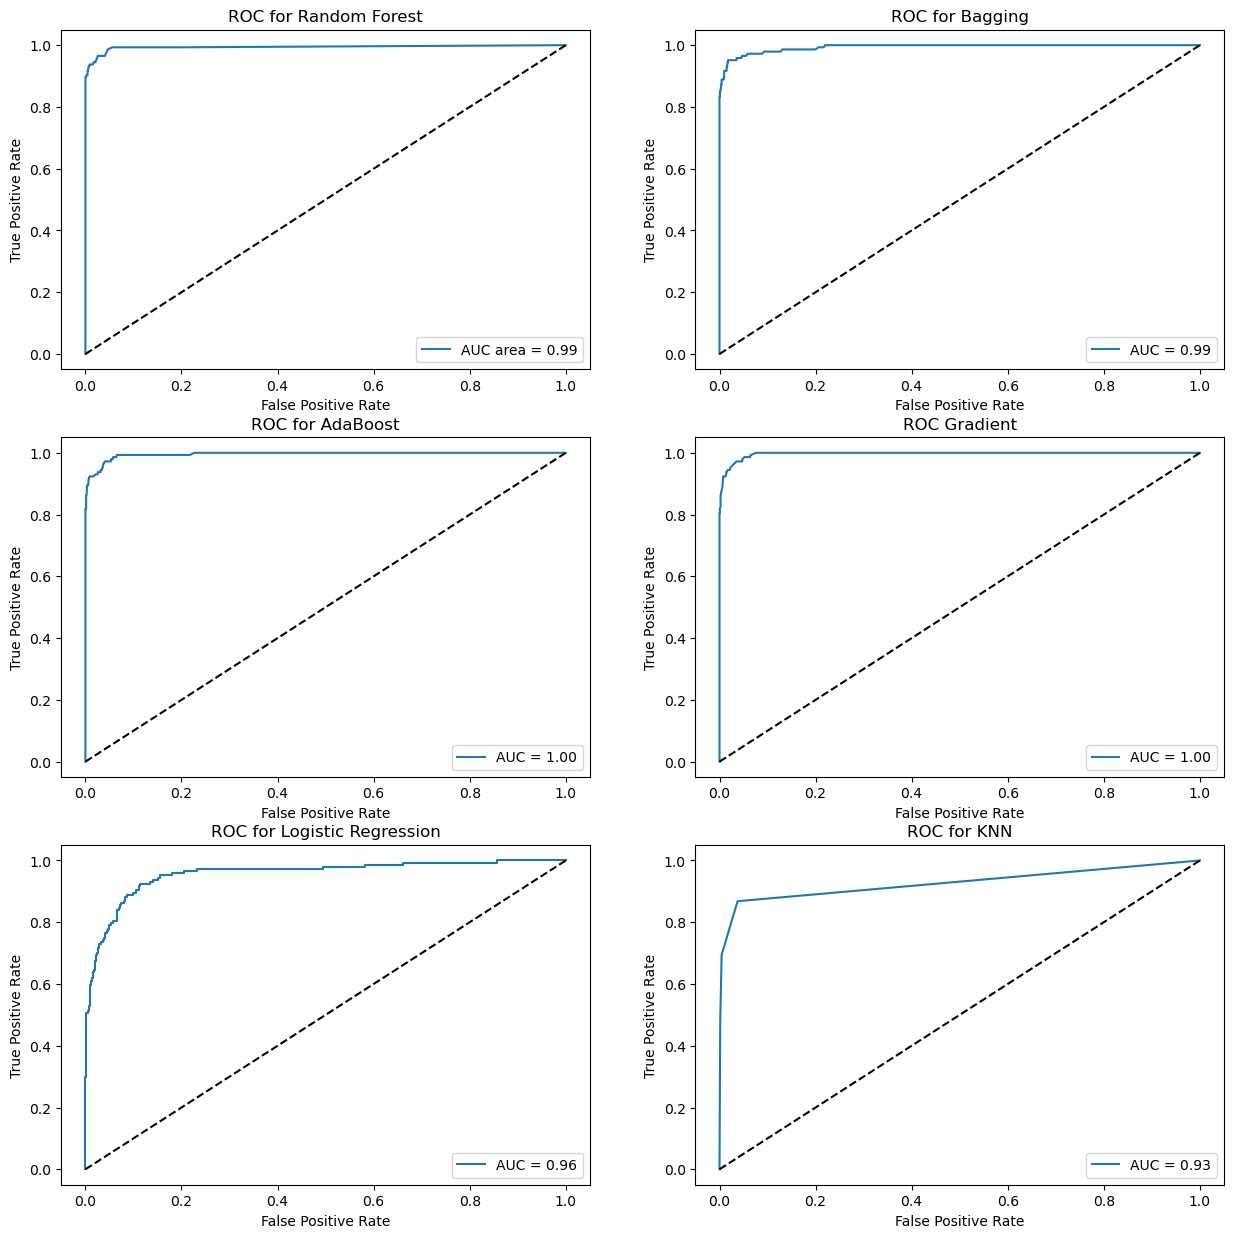

In [134]:
#Plot the ROC curve 
plt.clf()
fig, ax= plt.subplots(nrows = 3, ncols = 2, figsize = (15,15))
ax[0,0].plot(fpr, tpr, label='AUC area = %0.2f' % auc1)
ax[0,0].plot([0, 1], [0, 1], 'k--')
ax[0,0].set_xlabel('False Positive Rate')
ax[0,0].set_ylabel('True Positive Rate')
ax[0,0].set_title('ROC for Random Forest')
ax[0,0].legend(loc="lower right")

ax[0,1].plot(fpr1, tpr1, label='AUC = %0.2f' % auc2)
ax[0,1].plot([0, 1], [0, 1], 'k--')
ax[0,1].set_xlabel('False Positive Rate')
ax[0,1].set_ylabel('True Positive Rate')
ax[0,1].set_title('ROC for Bagging')
ax[0,1].legend(loc="lower right")

ax[1,0].plot(fpr2, tpr2, label='AUC = %0.2f' % auc3)
ax[1,0].plot([0, 1], [0, 1], 'k--')
ax[1,0].set_xlabel('False Positive Rate')
ax[1,0].set_ylabel('True Positive Rate')
ax[1,0].set_title('ROC for AdaBoost')
ax[1,0].legend(loc="lower right")

ax[1,1].plot(fpr3, tpr3, label='AUC = %0.2f' % auc4)
ax[1,1].plot([0, 1], [0, 1], 'k--')
ax[1,1].set_xlabel('False Positive Rate')
ax[1,1].set_ylabel('True Positive Rate')
ax[1,1].set_title('ROC Gradient')
ax[1,1].legend(loc="lower right")

ax[2,0].plot(lr_fpr, lr_tpr, label='AUC = %0.2f' % lr_auc)
ax[2,0].plot([0, 1], [0, 1], 'k--')
ax[2,0].set_xlabel('False Positive Rate')
ax[2,0].set_ylabel('True Positive Rate')
ax[2,0].set_title('ROC for Logistic Regression')
ax[2,0].legend(loc="lower right")

ax[2,1].plot(knn_fpr, knn_tpr, label='AUC = %0.2f' % knn_auc)
ax[2,1].plot([0, 1], [0, 1], 'k--')
ax[2,1].set_xlabel('False Positive Rate')
ax[2,1].set_ylabel('True Positive Rate')
ax[2,1].set_title('ROC for KNN')
ax[2,1].legend(loc="lower right")

plt.show()



In [136]:
print("Logistic Regression: \n",confusion_matrix(y_test,lr_pred))
print("\n K Nearest Neighbour: \n",confusion_matrix(y_test,knn_predict))
print('\n Decision Tree Confusion matrix : \n',confusion_matrix(y_test, dt_pred) )
print('\n Random Forest Confusion matrix : \n',confusion_matrix(y_test, rf_pred) )
print('\n Bagging Classifier Confusion matrix :  \n',confusion_matrix(y_test, bg_pred) )
print('\n AdaBoost Classifier Confusion matrix : \n',confusion_matrix(y_test, ada_pred) )
print('\n Gradient Boost Classifier Confusion matrix :  \n',confusion_matrix(y_test, gbc_pred) )

Logistic Regression: 
 [[1335   21]
 [  55   89]]

 K Nearest Neighbour: 
 [[1350    6]
 [  44  100]]

 Decision Tree Confusion matrix : 
 [[1356    0]
 [ 144    0]]

 Random Forest Confusion matrix : 
 [[1353    3]
 [  14  130]]

 Bagging Classifier Confusion matrix :  
 [[1356    0]
 [  38  106]]

 AdaBoost Classifier Confusion matrix : 
 [[1350    6]
 [  15  129]]

 Gradient Boost Classifier Confusion matrix :  
 [[1353    3]
 [  25  119]]


## Comparision of the models

In [139]:
df_compare = pd.DataFrame([[lr_accu_train,lr_accu_test,lr_f1],
                           [knn_accu_train,knn_accu_test,knn_f1],
                           [dt_training,dt_testing,dt_f1],
                           [rf_training,rf_testing,rf_f1],
                           [bg_training,bg_testing,bg_f1],
                          [ada_training,ada_testing,ada_f1],[gbc_training,gbc_testing,gbc_f1]],
    columns=['Training Accuracy','Testing Accuracy','F1Score'],
                       index=['Logistic Regression','KNearest Neighbour',
                              'DecisionTrees',
                              'RandomForest','BaggingClassifier','AdaBoost','GradientBoosting'])


In [141]:
# Top 3 models with Highest testing accuracy are - 
df_compare.sort_values(ascending=False,by=['Testing Accuracy'])['Testing Accuracy'].head(3)

RandomForest        0.988667
AdaBoost            0.986000
GradientBoosting    0.981333
Name: Testing Accuracy, dtype: float64

In [143]:
# Top 3 models with Highest training accuracy are - 
df_compare.sort_values(ascending=False,by=['Training Accuracy'])['Training Accuracy'].head(3)

RandomForest        1.000000
AdaBoost            0.986571
GradientBoosting    0.980857
Name: Training Accuracy, dtype: float64

In [145]:
# Top 3 models with highest F1 Score are 
df_compare.sort_values(ascending=False,by=['F1Score'])['F1Score'].head(3)

RandomForest        0.938628
AdaBoost            0.924731
GradientBoosting    0.894737
Name: F1Score, dtype: float64